In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
from google.colab import drive
from tensorflow.keras.models import load_model
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from tensorflow.keras.preprocessing import image

drive.mount('/content/drive')
MODEL_PATH = '/content/drive/MyDrive/Data MINIPROJECT/RecycleEasy_Project/ai_engine/models/waste_classifier_v1.h5'
model = load_model(MODEL_PATH)
LABELS = ['cardboard', 'glass', 'metal', 'organic', 'paper', 'plastic', 'trash']

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image

# The classes are sorted alphabetically by the generator
# 0: Cardboard, 1: Glass, 2: Metal, 3: Organic, 4: Paper, 5: Plastic, 6: Trash
LABELS = ['cardboard', 'glass', 'metal', 'organic', 'paper', 'plastic', 'trash']

def get_hira_guidance(material):
    """Priority Logic: Category -> Material -> Action -> Safety"""

    guidance = {
        'glass': {
            'lifecycle': 'REUSABLE / RECYCLABLE',
            'action': 'Wash and reuse as a storage jar or decorative item.',
            'safety': '🐾 ANIMAL SAFETY: Wrap in thick paper/cardboard to prevent injuries to street animals.',
            'bin': 'BLUE BIN'
        },
        'plastic': {
            'lifecycle': 'RECYCLABLE',
            'action': 'Check for recycling symbol. Remove caps and crush the bottle.',
            'safety': '⚠️ LIQUID WARNING: Ensure container is 100% EMPTY before disposal.',
            'bin': 'BLUE BIN'
        },
        'organic': {
            'lifecycle': 'DISPOSABLE / COMPOSTABLE',
            'action': 'Perfect for home composting or natural decay.',
            'safety': '🍎 NATURAL: Safe for animals like cows/dogs if clean.',
            'bin': 'GREEN BIN (Wet Waste)'
        },
        'metal': {
            'lifecycle': 'RECYCLABLE',
            'action': 'Rinse food residue. Flatten cans to save space.',
            'safety': '🚨 SHARP EDGES: Metal edges are dangerous. Handle with care.',
            'bin': 'BLUE BIN'
        },
        'paper': {
            'lifecycle': 'RECYCLABLE',
            'action': 'Keep dry. Do not recycle if oily (like pizza boxes).',
            'safety': 'Standard disposal.',
            'bin': 'BLUE BIN'
        },
        'cardboard': {
            'lifecycle': 'RECYCLABLE',
            'action': 'Flatten boxes. Remove plastic tape.',
            'safety': 'Standard disposal.',
            'bin': 'BLUE BIN'
        },
        'trash': {
            'lifecycle': 'NON-REUSABLE / TRASH',
            'action': 'General disposal. Try to avoid using this material.',
            'safety': 'Standard disposal.',
            'bin': 'BLACK BIN'
        }
    }
    return guidance.get(material.lower())

def test_on_real_image():
    uploaded = files.upload()
    for fn in uploaded.keys():
        # Preprocessing
        img = image.load_img(fn, target_size=(224, 224))
        x = image.img_to_array(img) / 255.0
        x = np.expand_dims(x, axis=0)

        # AI Prediction
        preds = model.predict(x)
        material_idx = np.argmax(preds)
        material_name = LABELS[material_idx]

        # Hira Logic
        info = get_hira_guidance(material_name)

        # FINAL OUTPUT
        print("\n" + "="*45)
        print(f"🌟 PRIMARY CATEGORY: {info['lifecycle']}")
        print(f"🛠️ DETECTED MATERIAL: {material_name.upper()}")
        print(f"📢 SAFETY WARNING: {info['safety']}")
        print(f"📦 USER ACTION: {info['action']}")
        print(f"🗑️ TARGET DISPOSAL: {info['bin']}")
        print("="*45 + "\n")

# Run this to test!
# test_on_real_image()

In [11]:
import pandas as pd
from google.colab import drive
from tensorflow.keras.models import load_model

drive.mount('/content/drive')

# Update this path to exactly where you saved your CSV
CSV_PATH = '/content/drive/MyDrive/Data MINIPROJECT/RecycleEasy_Project/ai_engine/global_data/global_bin_colors.csv'
MODEL_PATH = '/content/drive/MyDrive/Data MINIPROJECT/RecycleEasy_Project/ai_engine/models/waste_classifier_v1.h5'

# Load both the Brain and the Database
model = load_model(MODEL_PATH)
df_bins = pd.read_csv(CSV_PATH)

print("✅ Model and Global CSV Database loaded successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


✅ Model and Global CSV Database loaded successfully!


In [12]:
def get_hira_guidance_from_csv(material, country="India"):
    # 1. Basic Material Instructions (Animal Safety/Action)
    # These stay consistent across countries for the "Hira" logic
    base_info = {
        'glass': {'lifecycle': 'REUSABLE', 'action': 'Clean & Reuse', 'safety': '🐾 Wrap in paper for animal safety.'},
        'plastic': {'lifecycle': 'RECYCLABLE', 'action': 'Crush & Empty', 'safety': '⚠️ LIQUID WARNING: Empty container.'},
        'metal': {'lifecycle': 'RECYCLABLE', 'action': 'Flatten', 'safety': '🚨 SHARP EDGES: Handle with care.'},
        'organic': {'lifecycle': 'COMPOSTABLE', 'action': 'Compost', 'safety': '🍎 Safe for cows/dogs if clean.'},
        'paper': {'lifecycle': 'RECYCLABLE', 'action': 'Keep Dry', 'safety': 'Standard disposal.'},
        'cardboard': {'lifecycle': 'RECYCLABLE', 'action': 'Flatten', 'safety': 'Standard disposal.'},
        'trash': {'lifecycle': 'LANDFILL', 'action': 'Dispose', 'safety': 'Avoid using this material.'}
    }

    # 2. Lookup Bin Color from CSV based on Country
    country_data = df_bins[df_bins['Country'].str.lower() == country.lower()]

    if not country_data.empty:
        # Match material name to CSV column (ensure capitalization matches)
        column_name = material.capitalize()
        bin_color = country_data[column_name].values[0]
    else:
        bin_color = "Standard Waste Bin"

    info = base_info.get(material.lower())
    return {
        'lifecycle': info['lifecycle'],
        'action': info['action'],
        'safety': info['safety'],
        'bin': bin_color
    }

🌍 Running Global Test for Country: Germany


Saving plastic4.jpg to plastic4.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


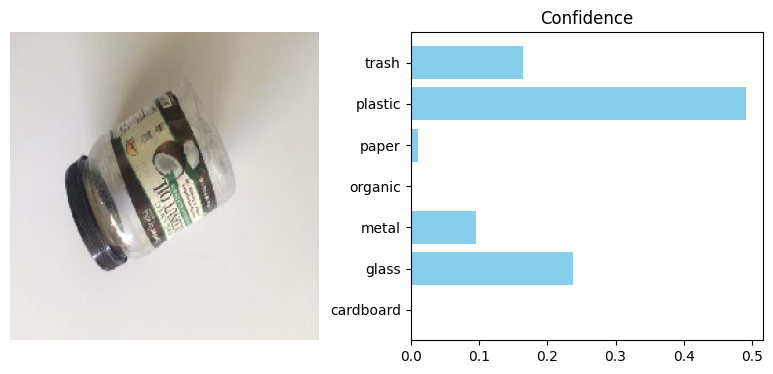

--------------------------------------------------
✅ AI PREDICTION : PLASTIC (49.11%)
🗺️ LOCATION      : Germany
🗑️ BIN COLOR     : YELLOW
📍 LIFECYCLE    : RECYCLABLE
🛠️ ACTION       : Crush & Empty
📢 SAFETY       : ⚠️ LIQUID WARNING: Empty container.
--------------------------------------------------



In [13]:
def test_and_debug_integrated(selected_country="India"):
    print(f"🌍 Running Global Test for Country: {selected_country}")
    uploaded = files.upload()

    for fn in uploaded.keys():
        img = image.load_img(fn, target_size=(224, 224))
        x = image.img_to_array(img) / 255.0
        x = np.expand_dims(x, axis=0)

        preds = model.predict(x)[0]
        max_idx = np.argmax(preds)
        confidence = preds[max_idx] * 100
        material_name = LABELS[max_idx]

        # Pull everything from the CSV and Logic
        info = get_hira_guidance_from_csv(material_name, selected_country)

        # Display Results
        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1); plt.imshow(img); plt.axis('off')
        plt.subplot(1, 2, 2); plt.barh(LABELS, preds, color='skyblue'); plt.title("Confidence")
        plt.show()

        print("-" * 50)
        print(f"✅ AI PREDICTION : {material_name.upper()} ({confidence:.2f}%)")
        print(f"🗺️ LOCATION      : {selected_country}")
        print(f"🗑️ BIN COLOR     : {info['bin'].upper()}")
        print(f"📍 LIFECYCLE    : {info['lifecycle']}")
        print(f"🛠️ ACTION       : {info['action']}")
        print(f"📢 SAFETY       : {info['safety']}")
        print("-" * 50 + "\n")

# To test for a specific country, just change the name here!
test_and_debug_integrated(selected_country="Germany")

In [14]:
!pip install googletrans==4.0.0-rc1

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.0/65.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 4.5 MB/s eta 0:00:00
  Created wheel for googletrans: filename=googletrans-4.0.0rc1-py3-none-any.whl size=17396 sha256=bf1adeca782631b37283ad6647c98addb6591cc7b0c6dfefc275f45cd6480202
  Stored in directory: /root/.cache/pip/wheels/95/0f/04/b17a72024b56a60e499ce1a6313d283ed5ba332407155bee03
Successfully built googletrans
  Attempting uninstall: hyperframe
    Found existing installation: hyperframe 6.1.0
    Uninstalling hyperfra

In [1]:
import pandas as pd
import numpy as np
from googletrans import Translator

# Initialize the Global Translator
translator = Translator()

print("✅ Recycling Engine: Libraries and Translator Initialized.")

✅ Recycling Engine: Libraries and Translator Initialized.


In [2]:
def get_global_guidance(material, country, df_bins):
    """
    Combines:
    1. Hira Logic (Base Instructions)
    2. CSV Lookup (Bin Colors & Language)
    3. Auto-Translation (Multilingual)
    """

    # 1. Base English Logic (Hira Knowledge Base)
    base_info = {
        'glass': {'lifecycle': 'REUSABLE', 'action': 'Clean & Reuse', 'safety': '🐾 Wrap in paper for animal safety.'},
        'plastic': {'lifecycle': 'RECYCLABLE', 'action': 'Crush & Empty', 'safety': '⚠️ LIQUID WARNING: Empty container.'},
        'metal': {'lifecycle': 'RECYCLABLE', 'action': 'Flatten', 'safety': '🚨 SHARP EDGES: Handle with care.'},
        'organic': {'lifecycle': 'COMPOSTABLE', 'action': 'Compost', 'safety': '🍎 Safe for cows/dogs if clean.'},
        'paper': {'lifecycle': 'RECYCLABLE', 'action': 'Keep Dry', 'safety': 'Standard disposal.'},
        'cardboard': {'lifecycle': 'RECYCLABLE', 'action': 'Flatten', 'safety': 'Standard disposal.'},
        'trash': {'lifecycle': 'LANDFILL', 'action': 'Dispose', 'safety': 'Avoid using this material.'}
    }

    # 2. Lookup Bin Color and Language Code from CSV
    country_data = df_bins[df_bins['Country'].str.lower() == country.lower()]

    if not country_data.empty:
        # Get the language code (e.g., 'hi', 'ja', 'de')
        lang_code = country_data['Language_Code'].values[0]
        # Match material name to CSV column (Capitalized)
        bin_color = country_data[material.capitalize()].values[0]
    else:
        # Fallback if country is not found
        lang_code = 'en'
        bin_color = "Standard Waste Bin"

    # Get the English version of instructions
    info = base_info.get(material.lower(), base_info['trash'])

    # 3. Multilingual Translation
    try:
        # Translate the Action, Safety, and Lifecycle
        trans_action = translator.translate(info['action'], dest=lang_code).text
        trans_safety = translator.translate(info['safety'], dest=lang_code).text
        trans_lifecycle = translator.translate(info['lifecycle'], dest=lang_code).text
    except Exception as e:
        # Fallback to English if translation fails (e.g., no internet)
        print(f"⚠️ Translation Error: {e}. Defaulting to English.")
        trans_action, trans_safety, trans_lifecycle = info['action'], info['safety'], info['lifecycle']

    return {
        'lifecycle': trans_lifecycle,
        'action': trans_action,
        'safety': trans_safety,
        'bin': bin_color,
        'lang_code': lang_code
    }

In [3]:
def load_recycling_db(csv_path):
    """Loads the Global Bin Color CSV database."""
    try:
        df = pd.read_csv(csv_path)
        print(f"📂 Database loaded successfully from {csv_path}")
        return df
    except Exception as e:
        print(f"❌ Error loading CSV: {e}")
        return None